In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from pprint import pprint
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import plotly.express as px

In [5]:
%matplotlib inline

In [6]:
cwd = Path.cwd()
project_root = cwd.parent

In [7]:
rfm_df = pd.read_csv(project_root / "data" / "rfm_features_with_targets.csv")
new_features = pd.read_csv(project_root / "data" / "new_features.csv")

In [8]:
rfm_df.columns

Index(['CustomerID', 'Recency', 'Frequency', 'MoneySpent', 'Cluster',
       'WillBuy'],
      dtype='str')

In [9]:
new_features.columns

Index(['CustomerID', 'NoOfUniqueProds', 'AverageOrderValue', 'Afternoon',
       'Evening', 'Morning', 'Friday', 'Monday', 'Sunday', 'Thursday',
       'Tuesday', 'Wednesday'],
      dtype='str')

In [10]:
rfm_df.head()

,CustomerID,Recency,Frequency,MoneySpent,Cluster,WillBuy
0,12346.0,280,1,16620.91,2,0
1,12347.0,84,124,2790.86,0,1
2,12348.0,29,31,1797.24,0,0
3,12350.0,264,17,334.40,1,0
4,12352.0,26,70,2194.31,0,1


In [11]:
new_features.head()

,CustomerID,NoOfUniqueProds,AverageOrderValue,Afternoon,Evening,Morning,Friday,Monday,Sunday,Thursday,Tuesday,Wednesday
0,12346.0,1,77183.600000,0,0,1,0,0,0,0,1,0
1,12347.0,82,558.172000,1,0,0,0,0,0,0,1,0
2,12348.0,22,449.310000,0,1,0,0,0,0,1,0,0
3,12350.0,17,334.400000,1,0,0,0,0,0,0,0,1
4,12352.0,47,313.472857,1,0,0,0,0,0,0,1,0


In [12]:
final_data = pd.merge(left=rfm_df, right=new_features, on="CustomerID", how="outer")

In [13]:
final_data.head()

,CustomerID,Recency,Frequency,MoneySpent,Cluster,WillBuy,NoOfUniqueProds,AverageOrderValue,Afternoon,Evening,Morning,Friday,Monday,Sunday,Thursday,Tuesday,Wednesday
0,12346.0,280,1,16620.91,2,0,1,77183.600000,0,0,1,0,0,0,0,1,0
1,12347.0,84,124,2790.86,0,1,82,558.172000,1,0,0,0,0,0,0,1,0
2,12348.0,29,31,1797.24,0,0,22,449.310000,0,1,0,0,0,0,1,0,0
3,12350.0,264,17,334.40,1,0,17,334.400000,1,0,0,0,0,0,0,0,1
4,12352.0,26,70,2194.31,0,1,47,313.472857,1,0,0,0,0,0,0,1,0


In [14]:
final_data.columns

Index(['CustomerID', 'Recency', 'Frequency', 'MoneySpent', 'Cluster',
       'WillBuy', 'NoOfUniqueProds', 'AverageOrderValue', 'Afternoon',
       'Evening', 'Morning', 'Friday', 'Monday', 'Sunday', 'Thursday',
       'Tuesday', 'Wednesday'],
      dtype='str')

In [15]:
X = final_data[['Recency', 'Frequency', 'MoneySpent', 'Cluster', 'NoOfUniqueProds', 'AverageOrderValue', 'Afternoon',
       'Evening', 'Morning', 'Friday', 'Monday', 'Sunday', 'Thursday',
       'Tuesday', 'Wednesday']].to_numpy()
Y = final_data["WillBuy"].to_numpy()

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=101, shuffle=True)

In [17]:
# Fitting the model
decision_tree = DecisionTreeClassifier()
decision_tree.fit(X=X_train, y=Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [18]:
y_train_pred = decision_tree.predict(X_train)
y_test_pred = decision_tree.predict(X_test)

train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)

In [19]:
train_acc, test_acc

(1.0, 0.6197183098591549)

In [20]:
train_report = classification_report(y_true=Y_train, y_pred=y_train_pred)
test_report = classification_report(y_true=Y_test, y_pred=y_test_pred)

In [21]:
print(train_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1812
           1       1.00      1.00      1.00      1308

    accuracy                           1.00      3120
   macro avg       1.00      1.00      1.00      3120
weighted avg       1.00      1.00      1.00      3120



In [22]:
print(test_report)

              precision    recall  f1-score   support

           0       0.68      0.68      0.68       460
           1       0.54      0.54      0.54       321

    accuracy                           0.62       781
   macro avg       0.61      0.61      0.61       781
weighted avg       0.62      0.62      0.62       781



In [23]:
max_depths = [i for i in range(2,10)]
train_accs = []
test_accs = []

train_conf_mats = []
test_conf_mats = []

train_f1_scores = []
test_f1_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
    test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
    train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
    test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
    train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
    test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_conf_mats.append(train_conf_mat)
    test_conf_mats.append(test_conf_mat)
    train_f1_scores.append(train_f1_score)
    test_f1_scores.append(test_f1_score)

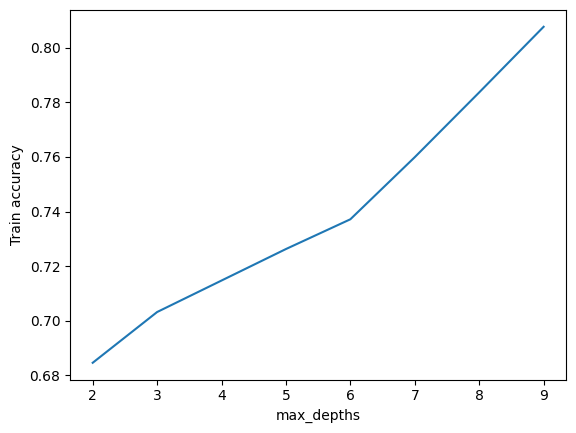

In [24]:
plt.plot([i for i in range(2, 10)], train_accs);
plt.xlabel("max_depths")
plt.ylabel("Train accuracy");

Text(0, 0.5, 'Test accuracy')

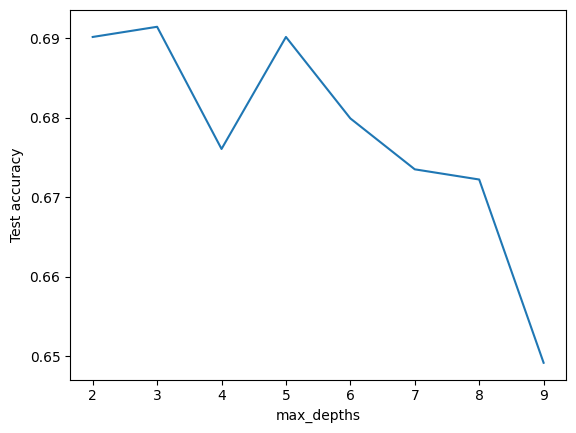

In [25]:
plt.plot([i for i in range(2, 10)],test_accs);
plt.xlabel("max_depths")
plt.ylabel("Test accuracy")

Text(0, 0.5, 'Train f1 scores')

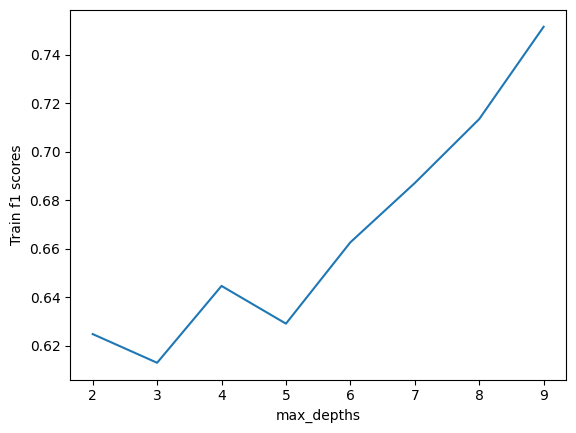

In [26]:
plt.plot([i for i in range(2, 10)],train_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Train f1 scores")

Text(0, 0.5, 'Test f1 scores')

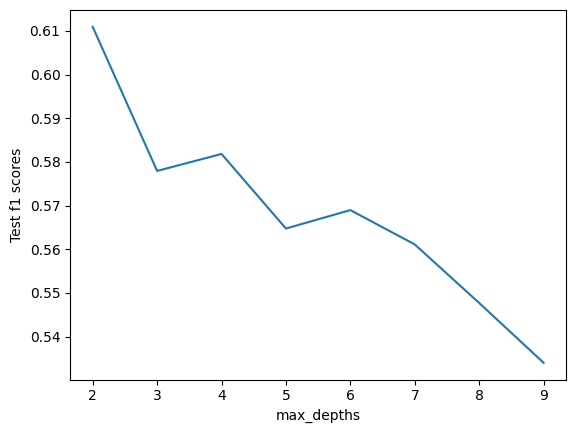

In [27]:
plt.plot([i for i in range(2, 10)],test_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Test f1 scores")

### Let's try Random Forest

In [28]:
rfmodel = RandomForestClassifier(class_weight="balanced")
rfmodel.fit(X_train, Y_train)

y_train_pred = rfmodel.predict(X_train)
y_test_pred = rfmodel.predict(X_test)

train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

In [29]:
train_acc, test_acc

(1.0, 0.6696542893725992)

In [30]:
train_f1_score, test_f1_score

(1.0, 0.5392857142857143)

In [31]:
max_depths = [i for i in range(2,11)]
train_accs = []
test_accs = []

train_conf_mats = []
test_conf_mats = []

train_f1_scores = []
test_f1_scores = []

for depth in max_depths:
    rfmodel = RandomForestClassifier(max_depth=depth, class_weight="balanced")
    rfmodel.fit(X_train, Y_train)
    y_train_pred = rfmodel.predict(X_train)
    y_test_pred = rfmodel.predict(X_test)
    train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
    test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
    train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
    test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
    train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
    test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_conf_mats.append(train_conf_mat)
    test_conf_mats.append(test_conf_mat)
    train_f1_scores.append(train_f1_score)
    test_f1_scores.append(test_f1_score)

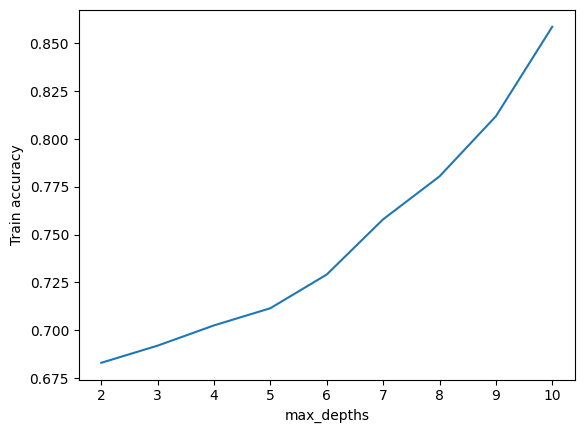

In [32]:
plt.plot([i for i in range(2, 11)], train_accs);
plt.xlabel("max_depths")
plt.ylabel("Train accuracy");

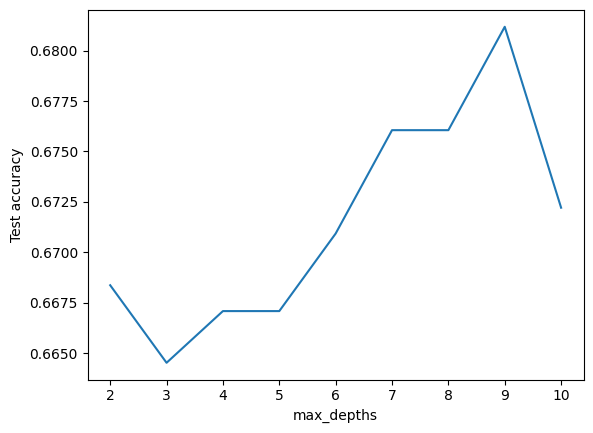

In [33]:
plt.plot([i for i in range(2, 11)],test_accs);
plt.xlabel("max_depths")
plt.ylabel("Test accuracy");

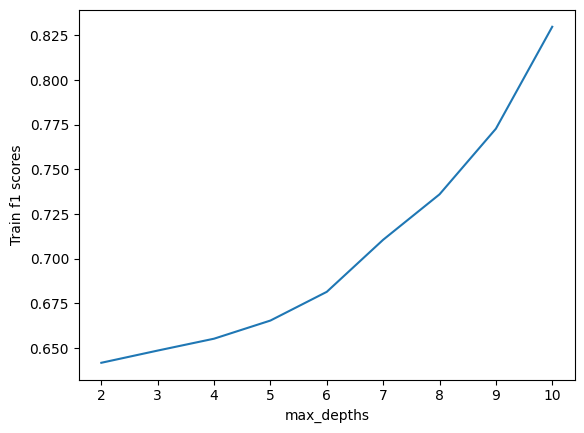

In [34]:
plt.plot([i for i in range(2, 11)],train_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Train f1 scores");

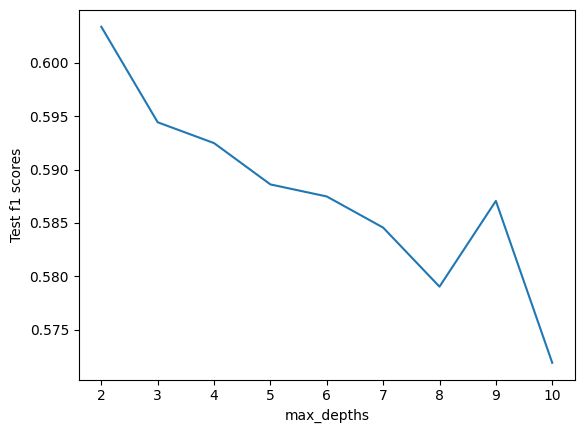

In [35]:
plt.plot([i for i in range(2, 11)],test_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Test f1 scores");

In [36]:
best_model = RandomForestClassifier(max_depth=3, class_weight="balanced")
best_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [37]:
best_model.feature_importances_

array([0.13902028, 0.28317511, 0.19608307, 0.13965452, 0.17329328,
       0.05835491, 0.00176887, 0.00147739, 0.00114813, 0.00119875,
       0.00064575, 0.00145867, 0.0004973 , 0.00117918, 0.00104479])

In [38]:
feature_names = ["Recency", "Frequency", "MoneySpent", "Cluster", 
                 "NoOfUniqueProds", "AverageOrderValue",
                 "Afternoon", "Evening", "Morning",
                 "Friday", "Monday", "Sunday", "Thursday", "Tuesday", "Wednesday"]

importances = pd.Series(best_model.feature_importances_, index=feature_names)
importances.sort_values(ascending=False)

Frequency            0.283175
MoneySpent           0.196083
NoOfUniqueProds      0.173293
Cluster              0.139655
Recency              0.139020
AverageOrderValue    0.058355
Afternoon            0.001769
Evening              0.001477
Sunday               0.001459
Friday               0.001199
Tuesday              0.001179
Morning              0.001148
Wednesday            0.001045
Monday               0.000646
Thursday             0.000497
dtype: float64

In [39]:
X = final_data[["Frequency", "MoneySpent", "Recency", "NoOfUniqueProds"]].to_numpy()
Y = final_data["WillBuy"].to_numpy()

In [40]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=101, shuffle=True)

In [41]:
max_depths = [i for i in range(2,10)]
train_accs = []
test_accs = []

train_conf_mats = []
test_conf_mats = []

train_f1_scores = []
test_f1_scores = []

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, Y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
    test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
    train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
    test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
    train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
    test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_conf_mats.append(train_conf_mat)
    test_conf_mats.append(test_conf_mat)
    train_f1_scores.append(train_f1_score)
    test_f1_scores.append(test_f1_score)

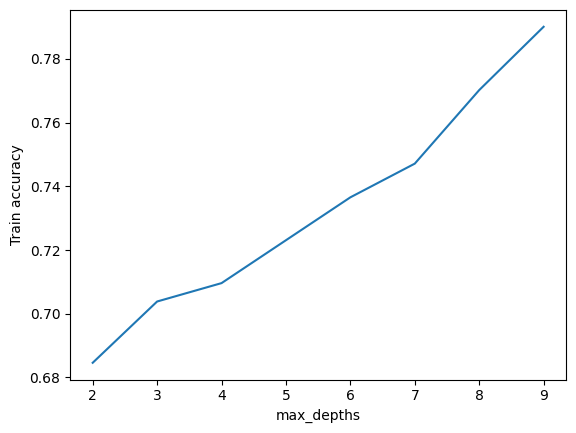

In [42]:
plt.plot([i for i in range(2, 10)], train_accs);
plt.xlabel("max_depths")
plt.ylabel("Train accuracy");

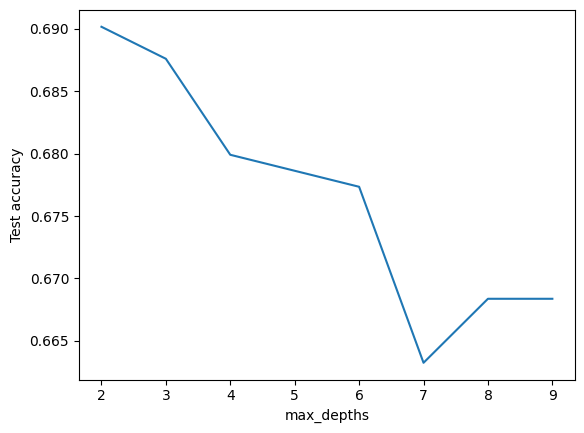

In [43]:
plt.plot([i for i in range(2, 10)],test_accs);
plt.xlabel("max_depths")
plt.ylabel("Test accuracy");

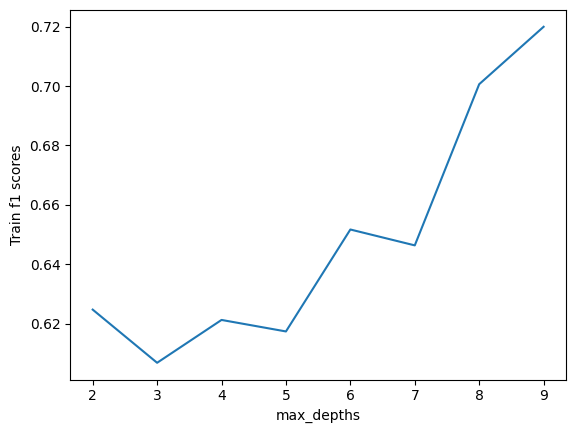

In [44]:
plt.plot([i for i in range(2, 10)],train_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Train f1 scores");

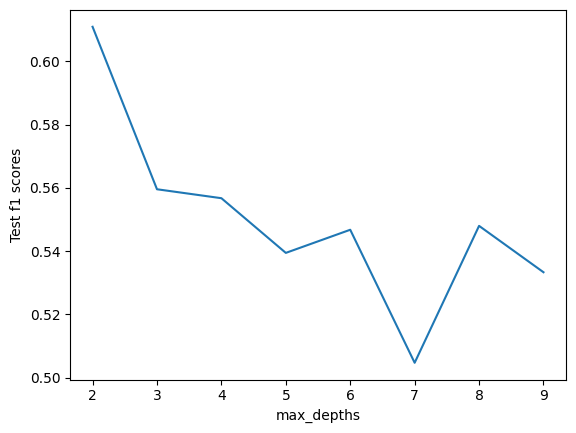

In [45]:
plt.plot([i for i in range(2, 10)],test_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Test f1 scores");

In [46]:
max_depths = [i for i in range(2,11)]
train_accs = []
test_accs = []

train_conf_mats = []
test_conf_mats = []

train_f1_scores = []
test_f1_scores = []

for depth in max_depths:
    rfmodel = RandomForestClassifier(max_depth=depth, class_weight="balanced")
    rfmodel.fit(X_train, Y_train)
    y_train_pred = rfmodel.predict(X_train)
    y_test_pred = rfmodel.predict(X_test)
    train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
    test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
    train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
    test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
    train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
    test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

    train_accs.append(train_acc)
    test_accs.append(test_acc)
    train_conf_mats.append(train_conf_mat)
    test_conf_mats.append(test_conf_mat)
    train_f1_scores.append(train_f1_score)
    test_f1_scores.append(test_f1_score)

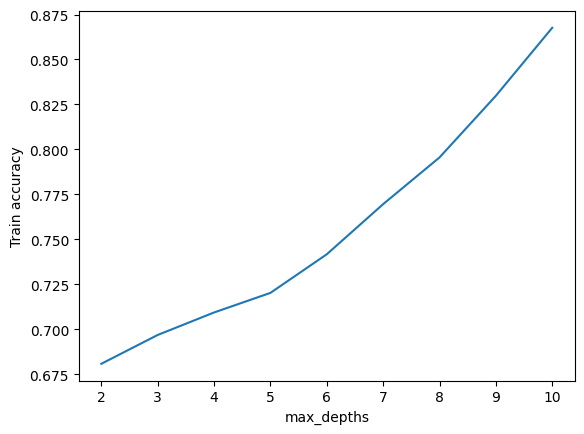

In [47]:
plt.plot([i for i in range(2, 11)], train_accs);
plt.xlabel("max_depths")
plt.ylabel("Train accuracy");

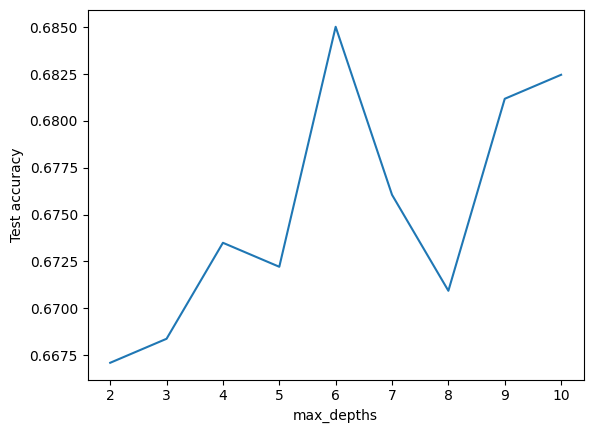

In [48]:
plt.plot([i for i in range(2, 11)],test_accs);
plt.xlabel("max_depths")
plt.ylabel("Test accuracy");

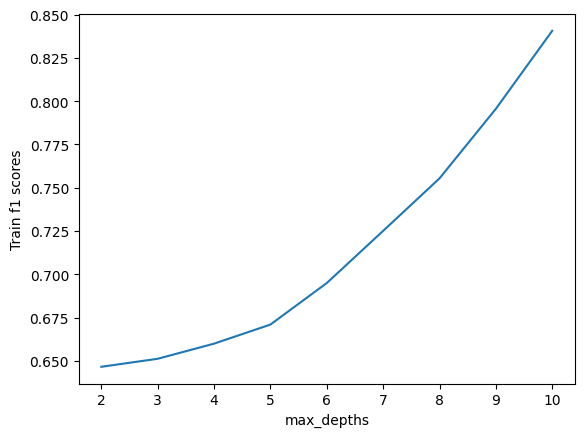

In [49]:
plt.plot([i for i in range(2, 11)],train_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Train f1 scores");

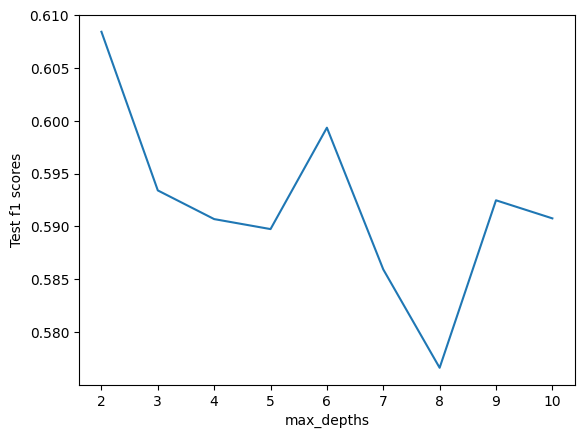

In [50]:
plt.plot([i for i in range(2, 11)],test_f1_scores);
plt.xlabel("max_depths")
plt.ylabel("Test f1 scores");

In [51]:
best_model = RandomForestClassifier(max_depth=3, class_weight="balanced")
best_model.fit(X_train, Y_train)

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_true=Y_train, y_pred=y_train_pred)
test_acc = accuracy_score(y_true=Y_test, y_pred=y_test_pred)
train_conf_mat = confusion_matrix(y_true=Y_train, y_pred=y_train_pred)
test_conf_mat = confusion_matrix(y_true=Y_test, y_pred=y_test_pred)
train_f1_score = f1_score(y_true=Y_train, y_pred=y_train_pred)
test_f1_score = f1_score(y_true=Y_test, y_pred=y_test_pred)

In [52]:
best_model.feature_importances_

array([0.40981233, 0.31474015, 0.1034304 , 0.17201713])

In [53]:
train_acc, test_acc

(0.6987179487179487, 0.6658130601792573)

In [54]:
train_conf_mat

array([[1298,  514],
       [ 426,  882]])

In [55]:
test_conf_mat

array([[332, 128],
       [133, 188]])

In [56]:
train_f1_score, test_f1_score

(0.6523668639053254, 0.5902668759811617)